# 📈 EDA Temporal + Feature Engineering — Segmentación HCP

**Objetivo:** Pasar de un modelo agregado (sum/mean/max → 65% balanced acc) a uno que
capture **la forma de la trayectoria temporal** de cada HCP a lo largo de 86 semanas.

### Hipótesis de diagnóstico
1. Los segmentos **sí se separan** por volumen, pero el agregado `sum/mean/max` colapsa la varianza temporal.
2. SEG_A y SEG_C (98.6% overlap reportado) probablemente difieren **en cómo evoluciona** su prescripción, no en cuánto.
3. SEG_B (categoría residual) puede estar mejor caracterizada por **volatilidad** o **inactividad** que por nivel.

### Plan del notebook
| Sección | Qué hacemos | Por qué |
|---|---|---|
| 1 | Carga + downcasting | El CSV pesa 439 MB, hay que ser eficientes |
| 2 | Construcción del eje temporal | WEEK_IDX 0..85 común a todos los HCPs |
| 3 | Diagnóstico: ¿por qué falla el agregado? | Mostrar overlap visual |
| 4 | Series de tiempo media ± IQR por segmento | El gráfico que pediste — ver divergencias |
| 5 | Heatmap mediana(feature × semana × segmento) | Identificar *cuándo* divergen |
| 6 | Poder discriminativo por semana (AUC por par) | ¿Qué semanas son las más informativas? |
| 7 | Feature engineering temporal | Slope, recency, volatilidad, actividad |
| 8 | Comparación: agregado vs agregado + temporales | Medir el lift en balanced accuracy |
| 9 | Próximos pasos | Ideas para subir aún más |


## 0. Setup y constantes

In [11]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============== TUS RUTAS (con r"..." para que Windows no se queje del \) ==============
WEEKLY_PATH     = Path(r"C:\Users\Ana.Gaby\Pfizer-Clustering-Project\data\raw\VELSIPITY_AFF_MULTIPLI_prepared_prepared_prepared.csv")
AGGREGATED_PATH = Path(r"C:\Users\Ana.Gaby\Pfizer-Clustering-Project\data\processed\doctors_aggregated.csv")
OUT_DIR         = Path(r"C:\Users\Ana.Gaby\Pfizer-Clustering-Project\output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Verificación rápida — si sale False arregla la ruta antes de seguir
print("Weekly file existe:    ", WEEKLY_PATH.exists())
print("Aggregated file existe:", AGGREGATED_PATH.exists())
# =======================================================================================

LABELS = ['SEG_A', 'SEG_B', 'SEG_C']
SEG_COLORS = {'SEG_A': '#1f77b4', 'SEG_B': '#ff7f0e', 'SEG_C': '#2ca02c'}

RX_FEATURES = [
    'UC_TRX', 'ORAL_TRX', 'IL23_TRX', 'BRAND1_TRX', 'BRAND2_TRX',
    'UC_NRX', 'ORAL_NRX', 'IL23_NRX', 'BRAND1_NRX', 'BRAND2_NRX',
    'BRAND1_NBRX', 'BRAND2_NBRX', 'ORAL_NBRX', 'IL23_NBRX',
]
ENGAGEMENT_FEATURES = ['DETAILS', 'SAMPLES', 'RTE', 'SPK', 'COPAY', 'DIRECTMAIL']
CLAIMS_FEATURES = [
    'N_CLMBRAND1', 'N_CLMBRAND2', 'N_CLMBRAND3', 'N_CLMBRAND4', 'N_CLMOTHERS',
    'N_CLMBRAND1_NEW', 'N_CLMBRAND2_NEW', 'N_CLMBRAND3_NEW', 'N_CLMBRAND4_NEW',
]

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

Weekly file existe:     True
Aggregated file existe: True


## 1. Carga eficiente del archivo semanal

El CSV pesa ~440 MB. Lo cargamos una sola vez y hacemos *downcasting* a `float32` /
`int32` para bajar la huella de memoria de ~1 GB → ~450 MB. Si tu equipo es modesto,
activa `LITE_MODE = True` para trabajar con una muestra estratificada por HCP.


In [12]:
LITE_MODE = False        # True = muestrear ~3000 HCPs para iterar más rápido
LITE_N_HCPS = 3000

print('Leyendo archivo semanal…')
df = pd.read_csv(WEEKLY_PATH)
print(f'  shape inicial: {df.shape}')

# Downcast numérico
for c in df.select_dtypes(include='float64').columns:
    df[c] = df[c].astype('float32')
for c in df.select_dtypes(include='int64').columns:
    df[c] = pd.to_numeric(df[c], downcast='integer')

# Solo nos quedamos con HCPs etiquetados (los que tienen ATSEG)
df = df.dropna(subset=['ATSEG']).copy()
df['ATSEG'] = df['ATSEG'].astype('category')

if LITE_MODE:
    np.random.seed(42)
    sample_ids = (df.groupby('ATSEG')['NUEVO_ID'].unique()
                    .apply(lambda x: np.random.choice(x, size=min(LITE_N_HCPS // 3, len(x)), replace=False)))
    sample_ids = np.concatenate(sample_ids.values)
    df = df[df['NUEVO_ID'].isin(sample_ids)].copy()
    print(f'  LITE MODE — usando {df["NUEVO_ID"].nunique():,} HCPs')

print(f'  shape final:   {df.shape}')
print(f'  memoria:       {df.memory_usage(deep=True).sum() / 1e6:.0f} MB')
print(f'  HCPs:          {df["NUEVO_ID"].nunique():,}')
print(f'  semanas:       {df["WEEK_ID"].nunique()}')
print()
print('Distribución de ATSEG (a nivel HCP):')
print(df.groupby('NUEVO_ID')['ATSEG'].first().value_counts(normalize=True).round(3))


Leyendo archivo semanal…
  shape inicial: (1800066, 68)
  shape final:   (1023314, 68)
  memoria:       269 MB
  HCPs:          11,899
  semanas:       86

Distribución de ATSEG (a nivel HCP):
ATSEG
SEG_A    0.538
SEG_B    0.281
SEG_C    0.180
Name: proportion, dtype: float64


## 2. Construcción del eje temporal

Convertimos `WEEK_ID` a datetime y le asignamos un índice entero `WEEK_IDX` (0..85).
Esto nos permite alinear todos los HCPs en una misma rejilla y aplicar groupby vectorizado
sin tener que parsear fechas en cada paso.


In [13]:
df['WEEK_ID'] = pd.to_datetime(df['WEEK_ID'])
all_weeks = sorted(df['WEEK_ID'].unique())
week_to_idx = {w: i for i, w in enumerate(all_weeks)}
df['WEEK_IDX'] = df['WEEK_ID'].map(week_to_idx).astype('int16')

n_weeks = len(all_weeks)
print(f'Rango temporal: {all_weeks[0].date()} → {all_weeks[-1].date()}')
print(f'Total semanas:  {n_weeks}')

# Sanity check: ¿todos los HCPs tienen las mismas 86 semanas?
weeks_per_hcp = df.groupby('NUEVO_ID')['WEEK_IDX'].nunique()
print(f'Semanas por HCP: min={weeks_per_hcp.min()}, max={weeks_per_hcp.max()}, '
      f'mediana={weeks_per_hcp.median():.0f}')


Rango temporal: 2024-01-05 → 2025-08-22
Total semanas:  86
Semanas por HCP: min=86, max=86, mediana=86


## 3. Diagnóstico: ¿por qué el agregado pierde poder discriminativo?

Antes de armar las series, verifiquemos en gráficos por qué `sum/mean/max` no es suficiente.
Para `UC_TRX` (ejemplo), graficamos la distribución del **mean por HCP** y el **max por
HCP** por segmento. Si las distribuciones se solapan mucho, esto es exactamente lo que ve
tu XGBoost actual.


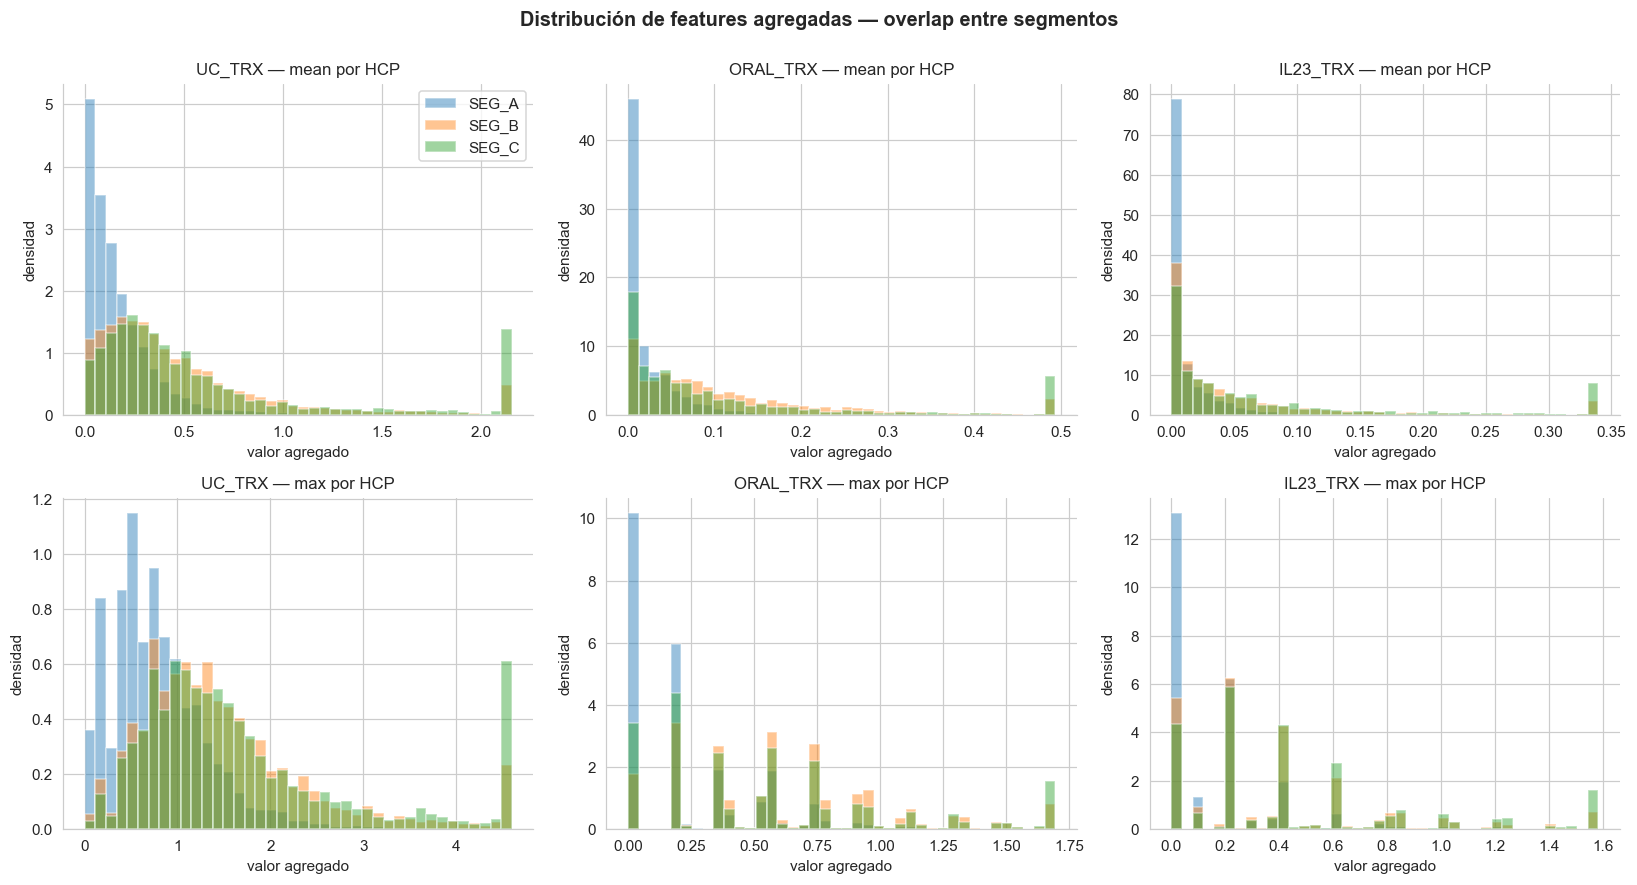

In [14]:
hcp_seg = df.groupby('NUEVO_ID')['ATSEG'].first()

def hcp_aggregate(feature, agg='mean'):
    s = df.groupby('NUEVO_ID')[feature].agg(agg)
    return pd.DataFrame({'value': s, 'segment': hcp_seg.loc[s.index].values})

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(['UC_TRX', 'ORAL_TRX', 'IL23_TRX']):
    for row, agg in enumerate(['mean', 'max']):
        ax = axes[row, i]
        d = hcp_aggregate(feat, agg)
        # Recortar cola superior para que el plot sea legible
        upper = d['value'].quantile(0.98)
        for seg in LABELS:
            sub = d[d['segment'] == seg]['value'].clip(upper=upper)
            ax.hist(sub, bins=40, alpha=0.45, label=seg,
                    color=SEG_COLORS[seg], density=True)
        ax.set_title(f'{feat} — {agg} por HCP', fontsize=11)
        ax.set_xlabel('valor agregado'); ax.set_ylabel('densidad')
        if i == 0 and row == 0:
            ax.legend()
fig.suptitle('Distribución de features agregadas — overlap entre segmentos',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()


**Lectura esperada:** las distribuciones de los tres segmentos se traslapan fuertemente
en cualquier feature agregada por sí sola. El modelo combina muchas para separarlas, pero
hasta aquí está perdiendo toda la *forma temporal* (¿cuándo prescribe?, ¿está creciendo?,
¿es estable o errático?).


## 4. Series de tiempo por segmento — media + banda IQR

Para cada feature relevante, calculamos la **media semanal** y el **rango intercuartílico
(P25–P75)** dentro de cada segmento. La banda IQR es más robusta que la desviación estándar
en estos datos (muchos ceros, colas largas).

### Cómo leer estos plots
- **Líneas que se mantienen separadas todo el tiempo** → la feature es discriminativa por nivel.
- **Líneas que se cruzan o convergen** → la separación depende del momento (¡oro puro para features temporales!).
- **Bandas que se solapan completamente** → la feature por sí sola no separa al segmento.


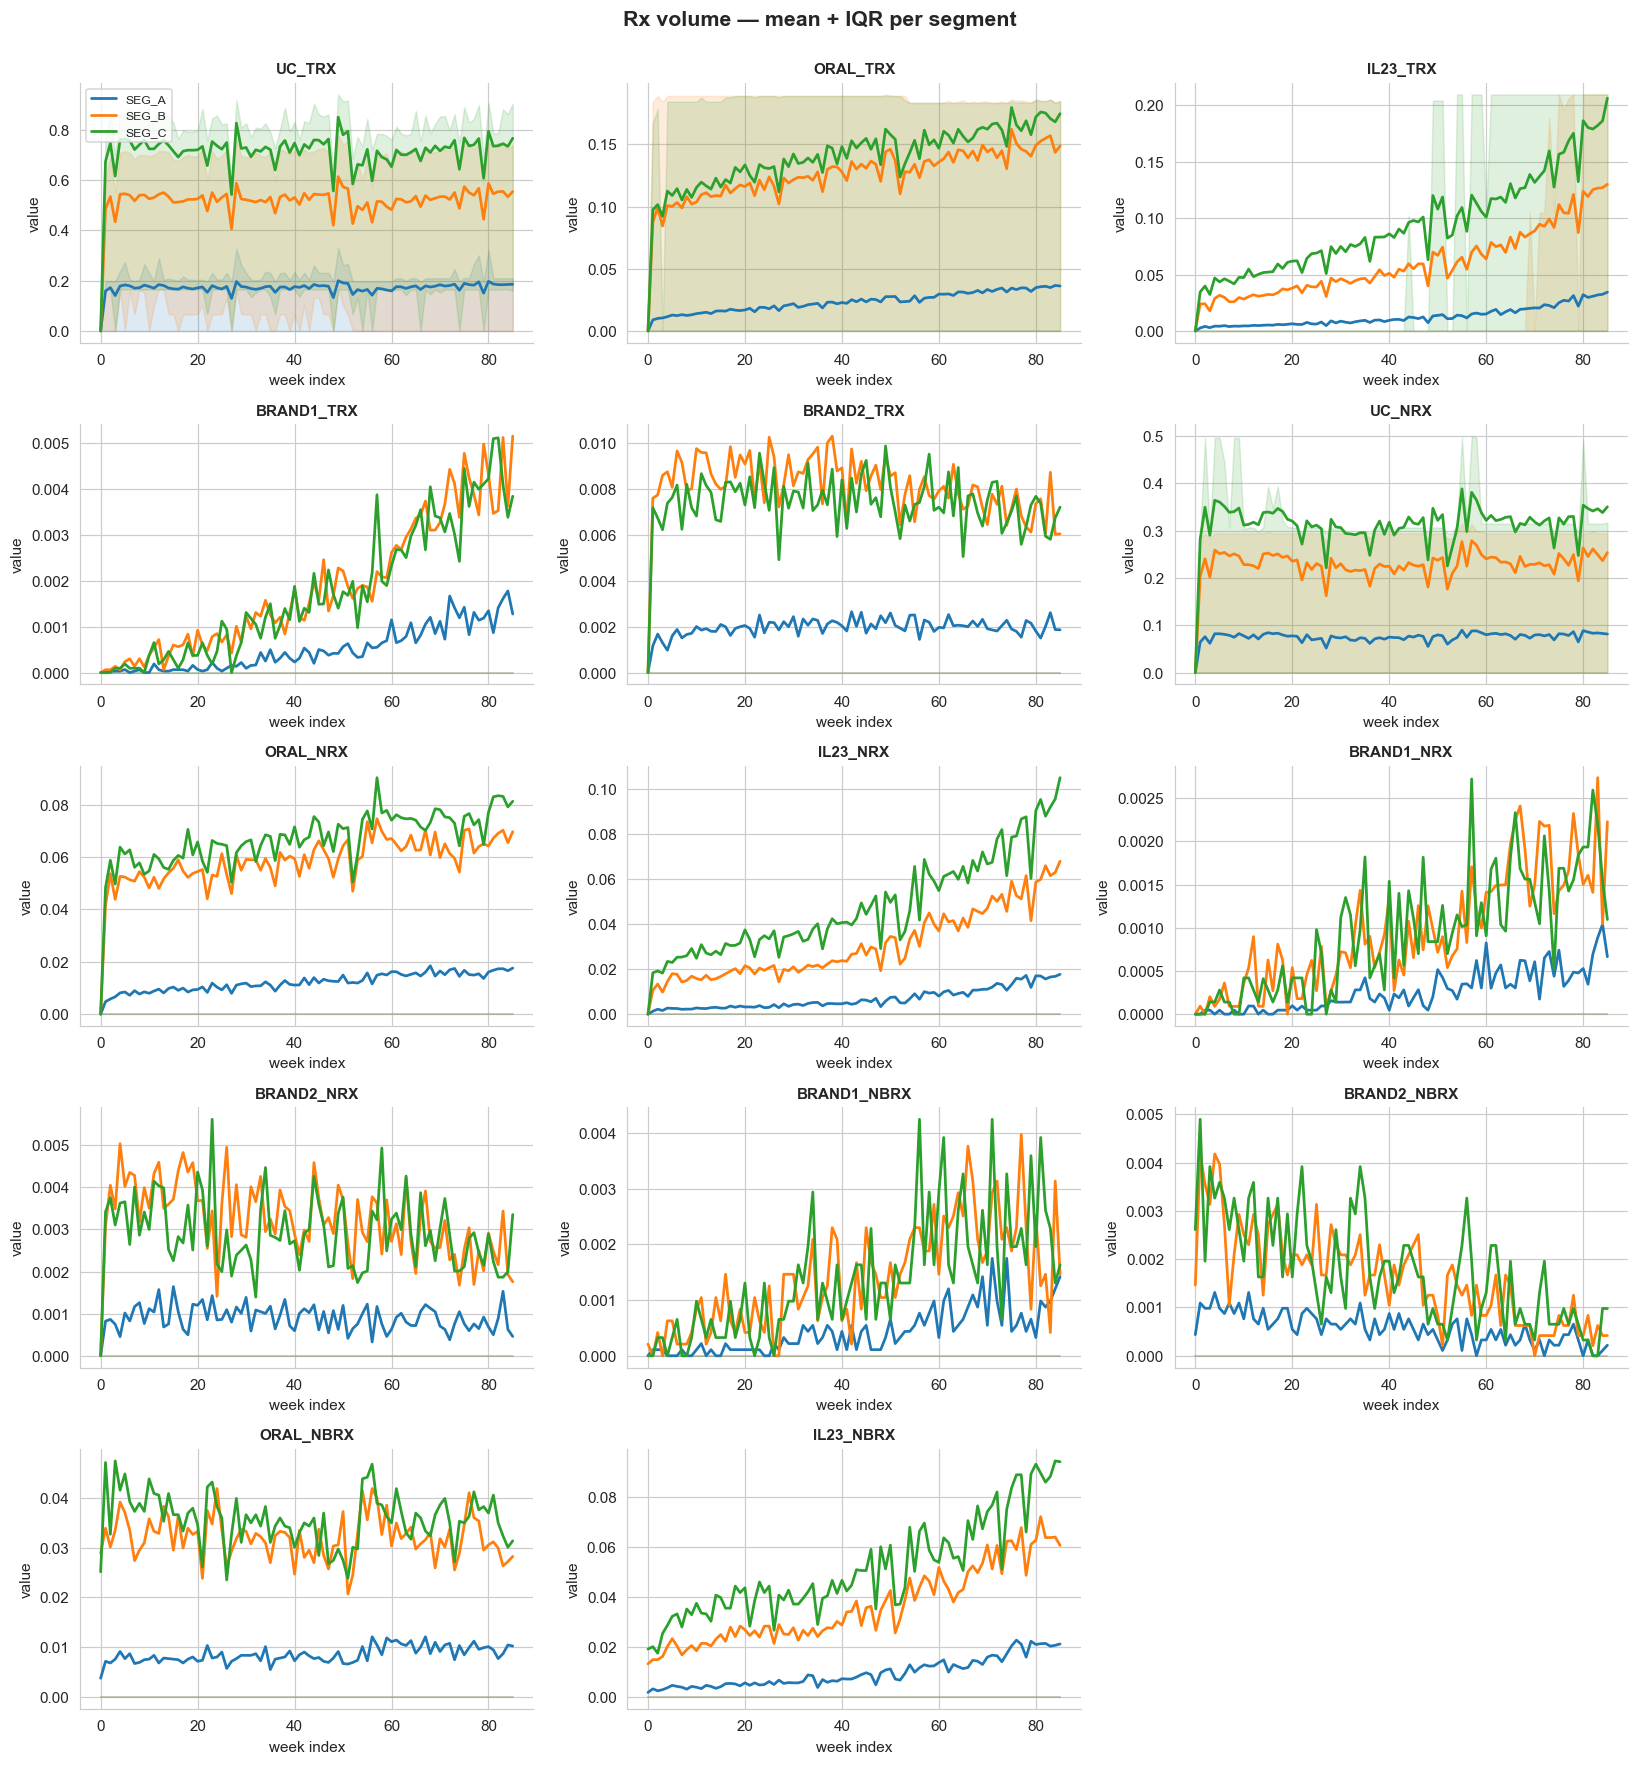

In [15]:
def plot_ts_per_segment(df, features, title_prefix, ncols=3, figsize_per=(5, 3.2)):
    n = len(features)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(figsize_per[0]*ncols, figsize_per[1]*nrows))
    axes = np.atleast_2d(axes).flatten()

    for i, feat in enumerate(features):
        ax = axes[i]
        if feat not in df.columns:
            ax.set_visible(False); continue

        # mean + IQR por (semana, segmento)
        agg = (df.groupby(['WEEK_IDX', 'ATSEG'], observed=True)[feat]
                 .agg(['mean',
                       lambda x: x.quantile(0.25),
                       lambda x: x.quantile(0.75)])
                 .rename(columns={'<lambda_0>': 'q25', '<lambda_1>': 'q75'})
                 .reset_index())

        for seg in LABELS:
            sub = agg[agg['ATSEG'] == seg].sort_values('WEEK_IDX')
            ax.plot(sub['WEEK_IDX'], sub['mean'], label=seg,
                    color=SEG_COLORS[seg], lw=1.8)
            ax.fill_between(sub['WEEK_IDX'], sub['q25'], sub['q75'],
                            color=SEG_COLORS[seg], alpha=0.15)
        ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.set_xlabel('week index'); ax.set_ylabel('value')
        if i == 0:
            ax.legend(loc='upper left', fontsize=8)
    for j in range(n, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title_prefix, fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout(); plt.show()

plot_ts_per_segment(df, RX_FEATURES, 'Rx volume — mean + IQR per segment')


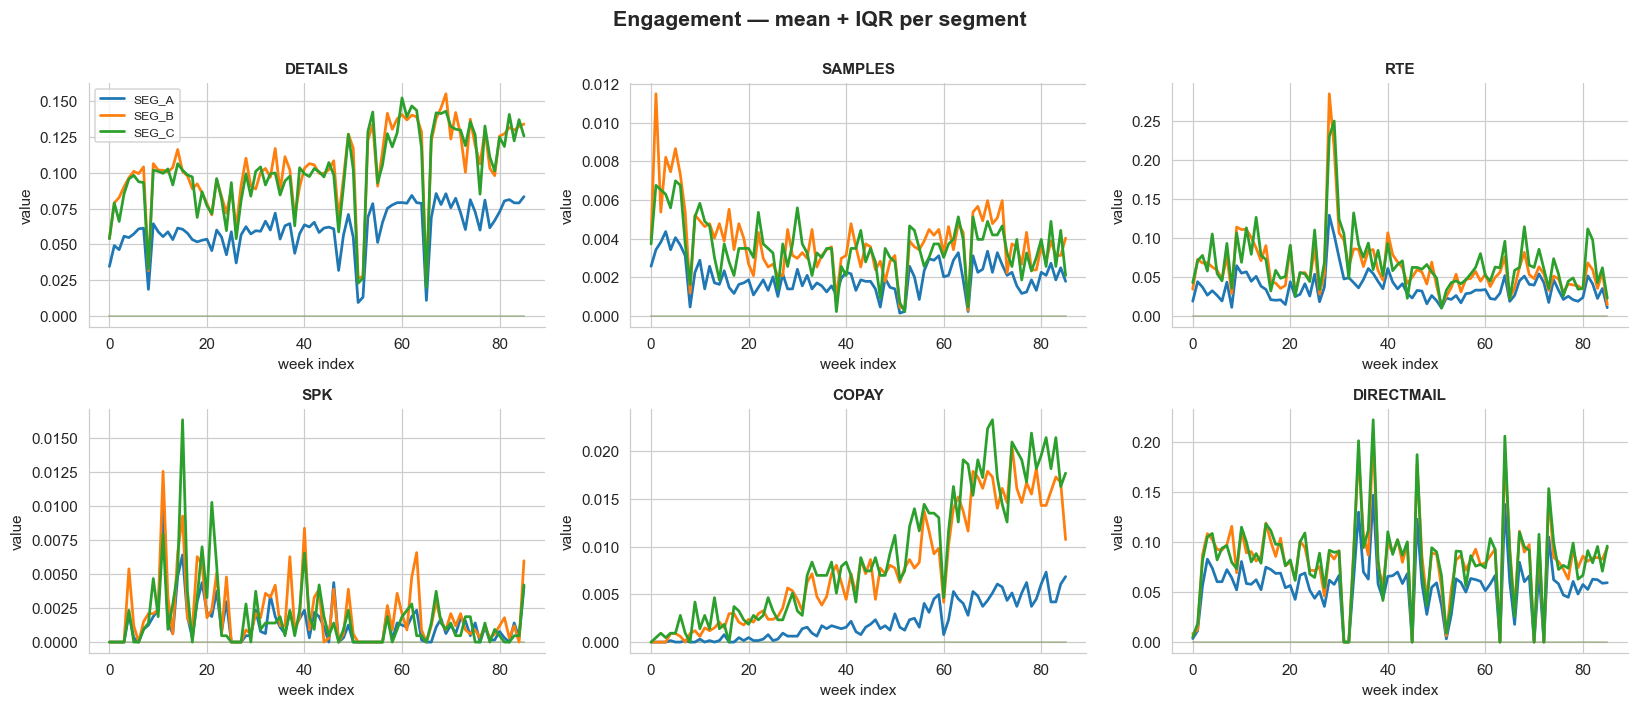

In [16]:
plot_ts_per_segment(df, ENGAGEMENT_FEATURES, 'Engagement — mean + IQR per segment')


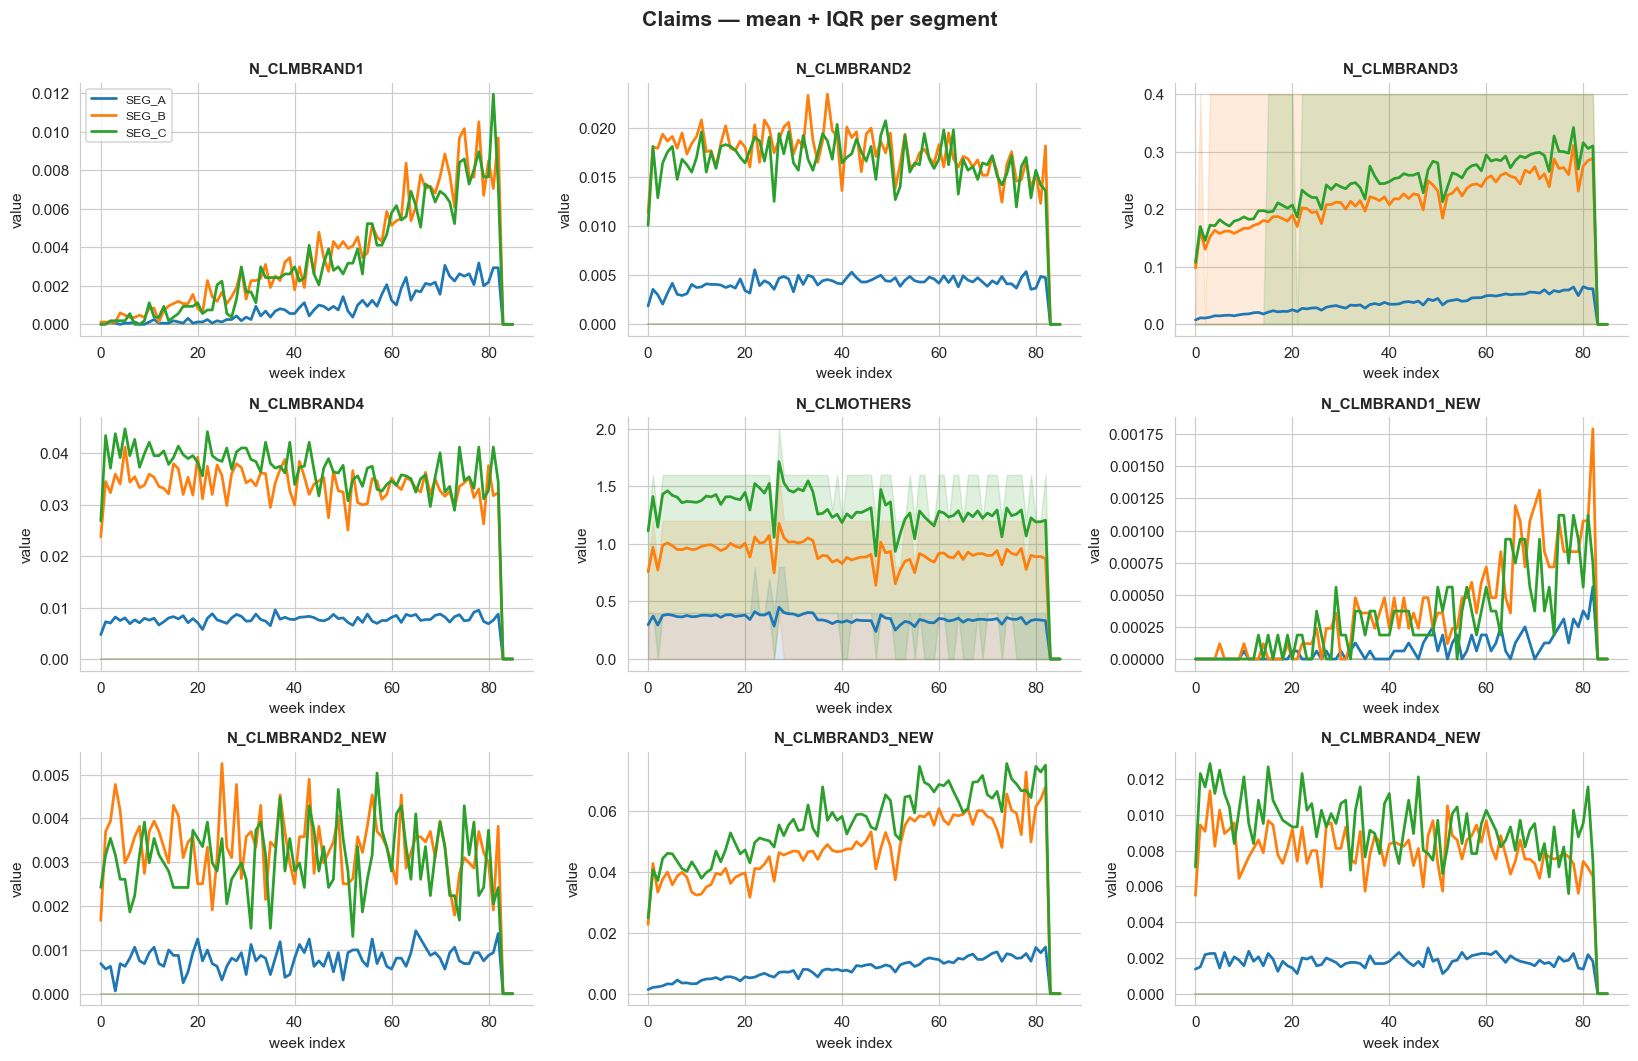

In [17]:
plot_ts_per_segment(df, CLAIMS_FEATURES, 'Claims — mean + IQR per segment')


## 5. Heatmap: mediana(feature × semana) por segmento

Otra forma de ver lo mismo, útil cuando hay muchas semanas. Si hay un *patrón* (estacional,
de adopción, de declive) será más obvio aquí que en líneas superpuestas.


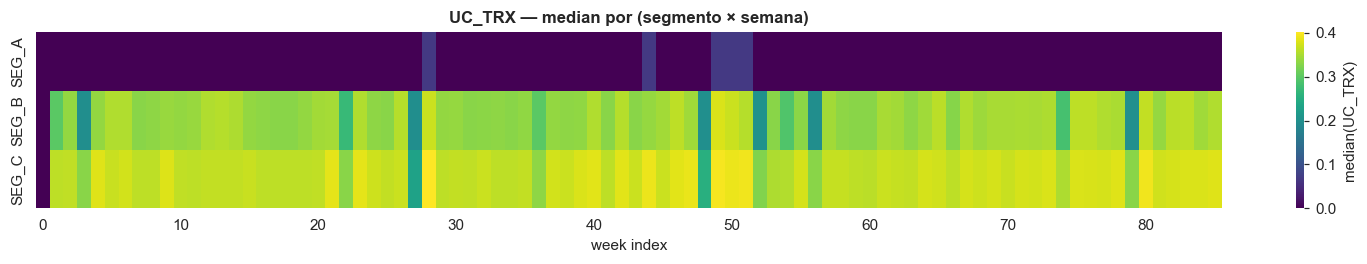

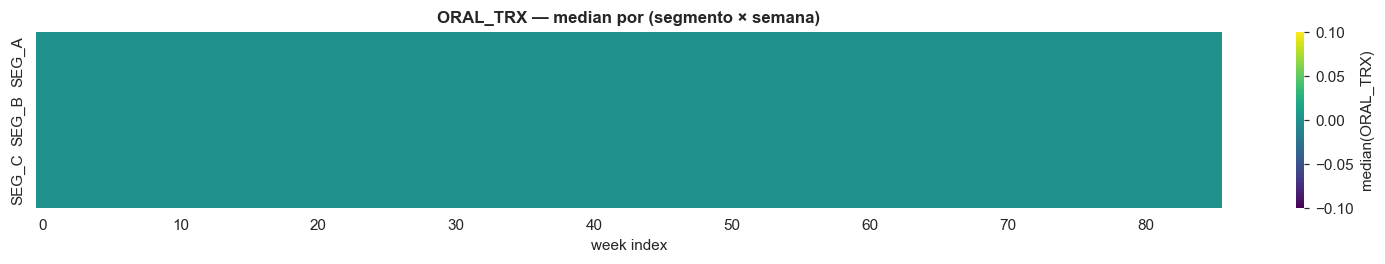

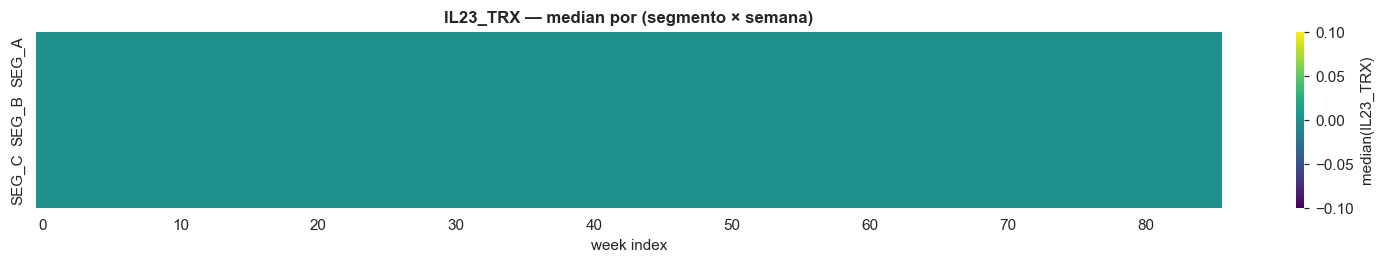

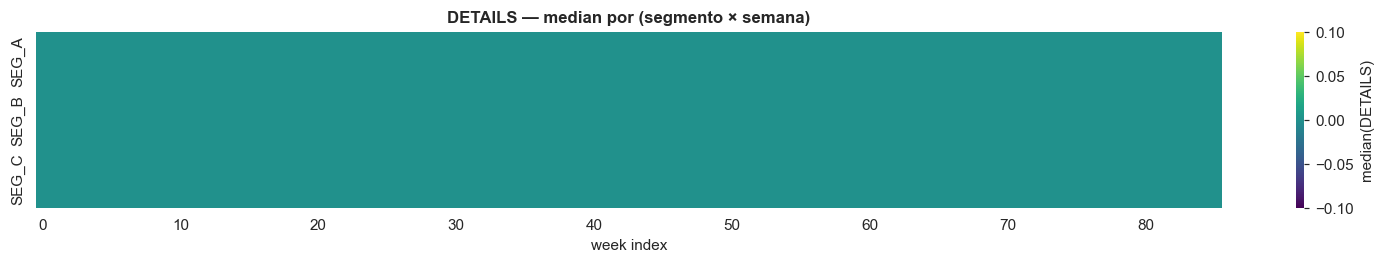

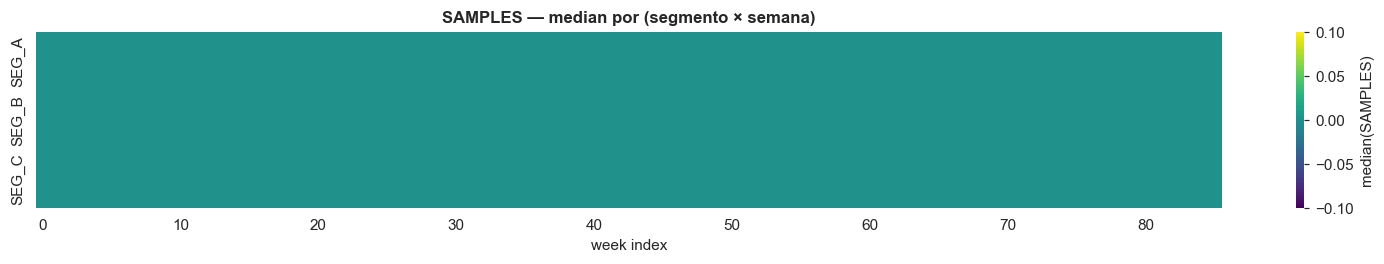

In [18]:
def heatmap_feature_by_segment(df, feature, agg='median'):
    pivot = (df.groupby(['ATSEG', 'WEEK_IDX'], observed=True)[feature]
               .agg(agg)
               .unstack('WEEK_IDX'))
    # Asegurar orden de filas
    pivot = pivot.reindex(LABELS)

    fig, ax = plt.subplots(figsize=(14, 2.5))
    sns.heatmap(pivot, cmap='viridis', cbar_kws={'label': f'{agg}({feature})'},
                ax=ax, xticklabels=10)
    ax.set_title(f'{feature} — {agg} por (segmento × semana)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('week index'); ax.set_ylabel('')
    plt.tight_layout(); plt.show()

for f in ['UC_TRX', 'ORAL_TRX', 'IL23_TRX', 'DETAILS', 'SAMPLES']:
    heatmap_feature_by_segment(df, f, agg='median')


## 6. ¿Qué semanas separan mejor los segmentos?

Para cada (semana, feature), calculamos el **AUC pareado** (one-vs-one) entre segmentos.
Esto nos dice: *si solo tuviera el valor de esta feature en esta semana, ¿qué tan bien
distinguiría SEG_A de SEG_C?*

Esto es clave porque tu pain point es exactamente el par **SEG_A vs SEG_C** (98.6% overlap).


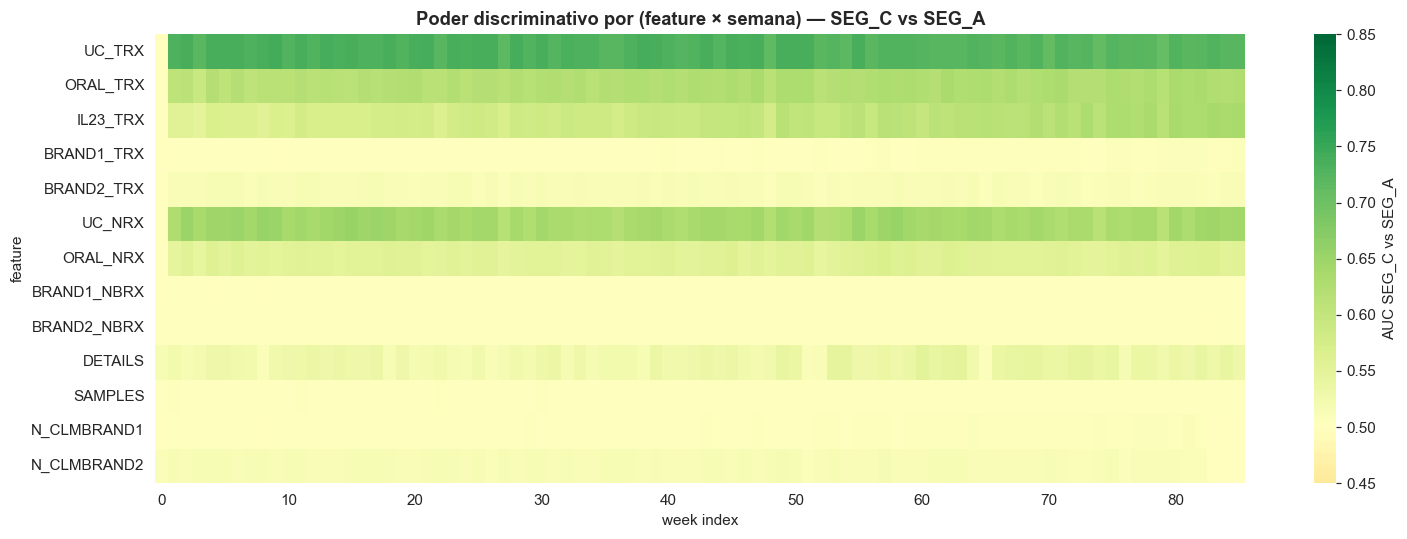


Ranking de features por capacidad discriminativa SEG_C vs SEG_A:
             auc_mean  auc_max  best_week
UC_TRX          0.726    0.743          9
UC_NRX          0.636    0.656         15
ORAL_TRX        0.620    0.633         82
IL23_TRX        0.594    0.638         83
ORAL_NRX        0.554    0.568         57
DETAILS         0.530    0.550         60
N_CLMBRAND2     0.513    0.517         57
BRAND2_TRX      0.512    0.517         40
BRAND1_TRX      0.503    0.508         82
N_CLMBRAND1     0.503    0.510         81
SAMPLES         0.502    0.504         22
BRAND2_NBRX     0.501    0.503          1
BRAND1_NBRX     0.501    0.502         56


In [19]:
from sklearn.metrics import roc_auc_score

def per_week_auc(df, feature, seg_pos='SEG_C', seg_neg='SEG_A'):
    aucs = []
    sub = df[df['ATSEG'].isin([seg_pos, seg_neg])][['WEEK_IDX', 'ATSEG', feature]]
    y = (sub['ATSEG'] == seg_pos).astype(int).values
    for w, idx in sub.groupby('WEEK_IDX').indices.items():
        yi = y[idx]
        if yi.min() == yi.max():       # una sola clase en esa semana
            aucs.append((w, np.nan)); continue
        vi = sub[feature].values[idx]
        try:
            auc = roc_auc_score(yi, vi)
        except ValueError:
            auc = np.nan
        aucs.append((w, max(auc, 1 - auc)))   # |AUC - 0.5| simétrico
    return pd.DataFrame(aucs, columns=['WEEK_IDX', 'auc']).set_index('WEEK_IDX')

candidates = ['UC_TRX', 'ORAL_TRX', 'IL23_TRX', 'BRAND1_TRX', 'BRAND2_TRX',
              'UC_NRX', 'ORAL_NRX', 'BRAND1_NBRX', 'BRAND2_NBRX',
              'DETAILS', 'SAMPLES', 'N_CLMBRAND1', 'N_CLMBRAND2']

auc_matrix = pd.DataFrame({f: per_week_auc(df, f, 'SEG_C', 'SEG_A')['auc']
                           for f in candidates})

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(auc_matrix.T, cmap='RdYlGn', center=0.5, vmin=0.45, vmax=0.85,
            cbar_kws={'label': 'AUC SEG_C vs SEG_A'}, ax=ax, xticklabels=10)
ax.set_title('Poder discriminativo por (feature × semana) — SEG_C vs SEG_A',
             fontsize=12, fontweight='bold')
ax.set_xlabel('week index'); ax.set_ylabel('feature')
plt.tight_layout(); plt.show()

# Top features ranqueadas por AUC máximo y AUC promedio
ranking = pd.DataFrame({
    'auc_mean': auc_matrix.mean(),
    'auc_max':  auc_matrix.max(),
    'best_week': auc_matrix.idxmax(),
}).sort_values('auc_mean', ascending=False)
print('\nRanking de features por capacidad discriminativa SEG_C vs SEG_A:')
print(ranking.round(3))


**Cómo usar este ranking:** las features y semanas con mayor AUC son las que más vale
la pena enfatizar al construir features temporales en la sección 7. Si una feature tiene
AUC bajo en *todas* las semanas, entonces ningún resumen temporal de ella va a ayudar mucho.


## 7. Feature engineering temporal (vectorizado)

Para cada HCP × feature calculamos:

| Feature derivada | Qué captura |
|---|---|
| `slope` | Tendencia (regresión lineal sobre las 86 semanas) |
| `recent_mean_12` | Promedio de las últimas 12 semanas |
| `early_mean_12`  | Promedio de las primeras 12 semanas |
| `acceleration` | `recent_mean_12 - early_mean_12` (momentum reciente) |
| `cv` | Coeficiente de variación = std / mean (volatilidad relativa) |
| `active_weeks_pct` | % de semanas con valor > 0 (regularidad) |
| `peak_week` | Semana en la que se observó el máximo |
| `weeks_since_peak` | Recencia del pico (86 - peak_week) |

Lo hacemos vectorizado con `groupby` para que sea rápido aún con 11k HCPs × 86 semanas.


In [20]:
def temporal_features(df, feature, n_weeks=86, recent_k=12, early_k=12):
    """Calcula features temporales para una sola variable, todos los HCPs en paralelo."""
    g = df.groupby('NUEVO_ID', sort=False)
    week_idx = df['WEEK_IDX'].values.astype('float32')
    val = df[feature].values.astype('float32')

    # Para slope vectorizada: trabajamos con sumas por HCP
    df_tmp = pd.DataFrame({
        'NUEVO_ID': df['NUEVO_ID'].values,
        'w': week_idx,
        'v': val,
        'wv': week_idx * val,
        'w2': week_idx * week_idx,
        'is_active': (val > 0).astype('int8'),
    })
    sums = df_tmp.groupby('NUEVO_ID', sort=False).agg(
        n=('v', 'size'),
        sum_w=('w', 'sum'),
        sum_v=('v', 'sum'),
        sum_wv=('wv', 'sum'),
        sum_w2=('w2', 'sum'),
        active=('is_active', 'sum'),
        max_v=('v', 'max'),
        std_v=('v', 'std'),
        peak_w=('v', 'idxmax'),  # vamos a corregir abajo
    )
    # OLS slope: ((n * sum_wv) - (sum_w * sum_v)) / ((n * sum_w2) - sum_w**2)
    num = sums['n'] * sums['sum_wv'] - sums['sum_w'] * sums['sum_v']
    den = sums['n'] * sums['sum_w2'] - sums['sum_w'] ** 2
    slope = (num / den.replace(0, np.nan)).fillna(0)

    mean_v = (sums['sum_v'] / sums['n']).replace(0, np.nan)
    cv = (sums['std_v'] / mean_v).fillna(0)

    active_pct = sums['active'] / sums['n']

    # peak_week: el idxmax de pandas devuelve el índice GLOBAL, no la semana.
    # Lo recalculamos con un truco vectorizado (semana de la fila con valor máx por HCP).
    peak_idx_in_df = df_tmp.loc[df_tmp.groupby('NUEVO_ID', sort=False)['v'].idxmax()]
    peak_week = peak_idx_in_df.set_index('NUEVO_ID')['w']

    # recent / early: usar máscaras
    recent_mask = df['WEEK_IDX'] >= (n_weeks - recent_k)
    early_mask  = df['WEEK_IDX'] <  early_k
    recent_mean = df[recent_mask].groupby('NUEVO_ID')[feature].mean()
    early_mean  = df[early_mask ].groupby('NUEVO_ID')[feature].mean()

    out = pd.DataFrame({
        f'{feature}__slope':         slope,
        f'{feature}__recent12_mean': recent_mean,
        f'{feature}__early12_mean':  early_mean,
        f'{feature}__acceleration':  (recent_mean - early_mean),
        f'{feature}__cv':            cv,
        f'{feature}__active_pct':    active_pct,
        f'{feature}__peak_week':     peak_week,
        f'{feature}__weeks_since_peak': (n_weeks - 1) - peak_week,
    }).fillna(0).astype('float32')
    return out


# Aplicamos a un núcleo de features (no a los 60+ — eso explotaría el feature space).
# Usa el ranking de la sección 6 para escoger.
CORE_TS_FEATURES = ['UC_TRX', 'ORAL_TRX', 'IL23_TRX', 'BRAND1_TRX', 'BRAND2_TRX',
                    'UC_NRX', 'ORAL_NRX', 'BRAND1_NBRX', 'BRAND2_NBRX',
                    'DETAILS', 'SAMPLES']

print('Generando features temporales…')
temporal_blocks = [temporal_features(df, f) for f in CORE_TS_FEATURES]
X_temporal = pd.concat(temporal_blocks, axis=1)
print(f'Generamos {X_temporal.shape[1]} features temporales para {X_temporal.shape[0]:,} HCPs.')
X_temporal.head()


Generando features temporales…
Generamos 88 features temporales para 11,899 HCPs.


,UC_TRX__slope,UC_TRX__recent12_mean,UC_TRX__early12_mean,UC_TRX__acceleration,UC_TRX__cv,UC_TRX__active_pct,UC_TRX__peak_week,UC_TRX__weeks_since_peak,ORAL_TRX__slope,ORAL_TRX__recent12_mean,...,DETAILS__peak_week,DETAILS__weeks_since_peak,SAMPLES__slope,SAMPLES__recent12_mean,SAMPLES__early12_mean,SAMPLES__acceleration,SAMPLES__cv,SAMPLES__active_pct,SAMPLES__peak_week,SAMPLES__weeks_since_peak
NUEVO_ID,,,,,,,,,,,,,,,,,,,,,
3,0.000122,0.137750,0.137667,0.000083,0.873709,0.709302,71.0,14.0,0.000000,0.000000,...,22.0,63.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,71.0,14.0
11,-0.003699,0.000000,0.297883,-0.297883,2.514750,0.220930,5.0,80.0,0.000000,0.000000,...,75.0,10.0,0.000165,0.041667,0.0,0.041667,6.879542,0.023256,35.0,50.0
18,-0.000770,0.310467,0.458067,-0.147600,0.713930,0.860465,2.0,83.0,0.000701,0.061233,...,6.0,79.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,6.0,79.0
19,0.001057,0.124050,0.000000,0.124050,2.619676,0.209302,81.0,4.0,0.000846,0.091983,...,32.0,53.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,3.0,82.0
20,-0.000879,0.102867,0.161650,-0.058783,1.736447,0.325581,1.0,84.0,0.000000,0.000000,...,26.0,59.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,26.0,59.0


### Visualización: ¿se separan los segmentos en las features nuevas?

Comparamos densidades de las nuevas features `acceleration` y `slope` por segmento. Si
estas son mucho más separadoras que el `mean/max` original, vamos por buen camino.


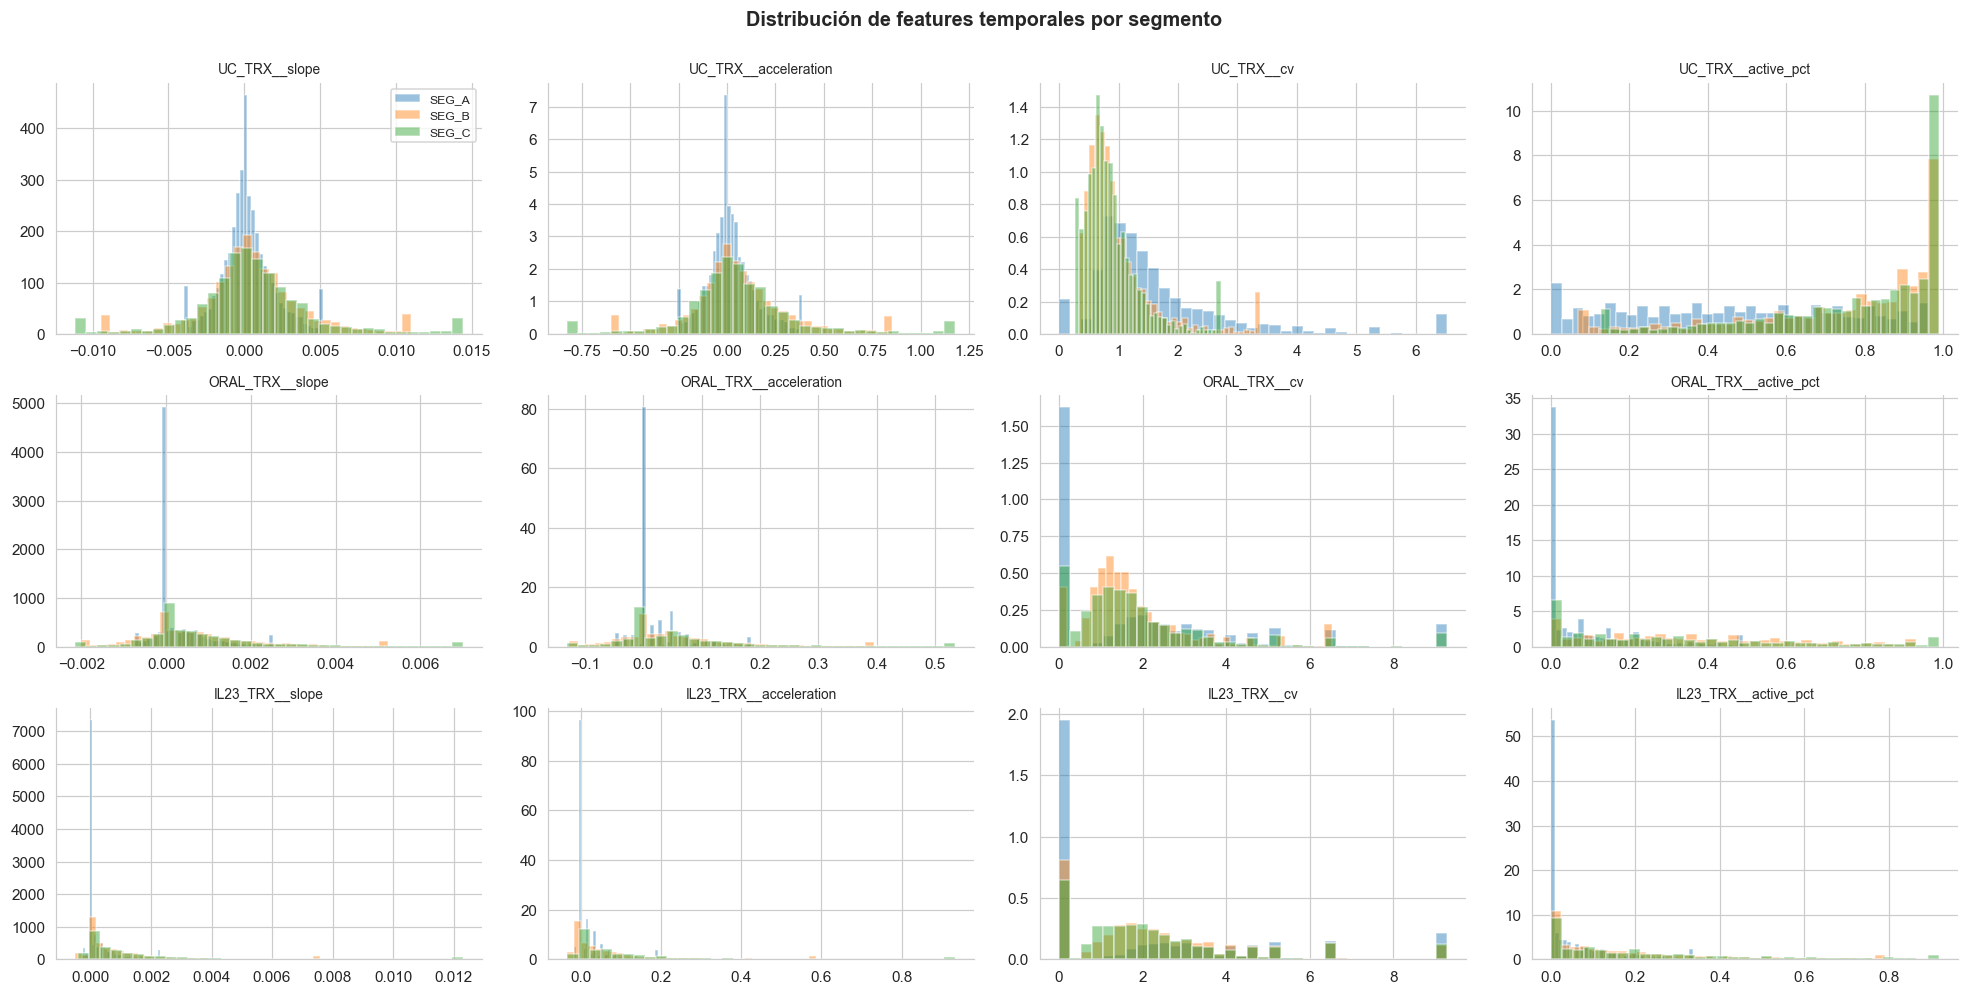

In [21]:
y_seg = hcp_seg.loc[X_temporal.index]
to_plot = [c for c in X_temporal.columns
           if any(s in c for s in ['__acceleration', '__slope', '__cv', '__active_pct'])][:12]

fig, axes = plt.subplots(3, 4, figsize=(18, 9))
for ax, col in zip(axes.flat, to_plot):
    for seg in LABELS:
        sub = X_temporal.loc[y_seg == seg, col]
        # recortar colas extremas para visualización
        lo, hi = sub.quantile([0.02, 0.98])
        sub = sub.clip(lo, hi)
        ax.hist(sub, bins=35, alpha=0.45, color=SEG_COLORS[seg],
                density=True, label=seg)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel(''); ax.set_ylabel('')
axes[0,0].legend(fontsize=8)
fig.suptitle('Distribución de features temporales por segmento',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()


## 8. Comparación: modelo agregado vs agregado + temporales

Replicamos tu pipeline XGBoost actual y le añadimos las features temporales. Reportamos
**balanced accuracy** (tu métrica) + recall por clase, que es lo que más te interesa
por el desbalance.


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, balanced_accuracy_score,
                             confusion_matrix)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

# --- 8.1 Cargar agregado y limpiarlo igual que en random_xgb.py ----------
agg = pd.read_csv(AGGREGATED_PATH)
agg = agg[agg['ATSEG_first'] != '0'].copy()

drop_cols = ['NUEVO_ID', 'ATSEG_first',
             'WEEK_ID_first', 'WEEK_ID_last', 'WEEK_ID_count']
feat_cols = [c for c in agg.columns if c not in drop_cols]
X_agg = agg.set_index('NUEVO_ID')[feat_cols].copy()

for col in X_agg.select_dtypes(include=['object']).columns:
    X_agg[col] = LabelEncoder().fit_transform(X_agg[col].fillna('MISSING').astype(str))
X_agg = X_agg.fillna(0).astype('float32')
X_agg.columns = (X_agg.columns
                 .str.replace(r'[\[\]<>(),]', '_', regex=True)
                 .str.replace(r'\s+', '_', regex=True)
                 .str.replace(r'_+', '_', regex=True)
                 .str.strip('_'))

y_agg = agg.set_index('NUEVO_ID')['ATSEG_first']

# Alinear X_temporal con el aggregated set
common_ids = X_agg.index.intersection(X_temporal.index)
X_agg_aligned = X_agg.loc[common_ids]
X_ts_aligned  = X_temporal.loc[common_ids]
y_aligned     = y_agg.loc[common_ids]
print(f'HCPs comunes: {len(common_ids):,}')

# --- 8.2 Helper de entrenamiento --------------------------------------------
def train_xgb_eval(X, y, label, random_state=42):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y)
    le = LabelEncoder()
    ytr_e = le.fit_transform(ytr)
    sw = compute_sample_weight('balanced', y=ytr_e)
    clf = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.08,
                        objective='multi:softprob', num_class=3,
                        random_state=random_state, n_jobs=-1,
                        eval_metric='mlogloss')
    clf.fit(Xtr, ytr_e, sample_weight=sw)
    yhat = le.inverse_transform(clf.predict(Xte))
    bal = balanced_accuracy_score(yte, yhat)
    rep = classification_report(yte, yhat, labels=LABELS,
                                output_dict=True, zero_division=0)
    return {
        'label': label,
        'balanced_acc': bal * 100,
        'recall_A': rep['SEG_A']['recall'] * 100,
        'recall_B': rep['SEG_B']['recall'] * 100,
        'recall_C': rep['SEG_C']['recall'] * 100,
        'f1_macro': rep['macro avg']['f1-score'] * 100,
        'cm': confusion_matrix(yte, yhat, labels=LABELS),
        'model': clf,
        'X_test': Xte, 'y_test': yte,
    }

# --- 8.3 Tres experimentos --------------------------------------------------
print('Entrenando A) solo agregado…')
A = train_xgb_eval(X_agg_aligned, y_aligned, 'A: solo agregado')
print('Entrenando B) solo temporales…')
B = train_xgb_eval(X_ts_aligned,  y_aligned, 'B: solo temporales')
print('Entrenando C) agregado + temporales…')
X_combined = pd.concat([X_agg_aligned, X_ts_aligned], axis=1)
C = train_xgb_eval(X_combined, y_aligned, 'C: agregado + temporales')

results = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('cm', 'model', 'X_test', 'y_test')}
    for r in (A, B, C)
])
print()
print(results.round(2).to_string(index=False))


HCPs comunes: 11,899
Entrenando A) solo agregado…
Entrenando B) solo temporales…
Entrenando C) agregado + temporales…

                   label  balanced_acc  recall_A  recall_B  recall_C  f1_macro
        A: solo agregado         57.90     79.47     52.99     41.26     58.08
      B: solo temporales         54.13     78.30     54.48     29.60     54.21
C: agregado + temporales         57.47     82.36     55.07     34.97     57.84


### Visualización del lift


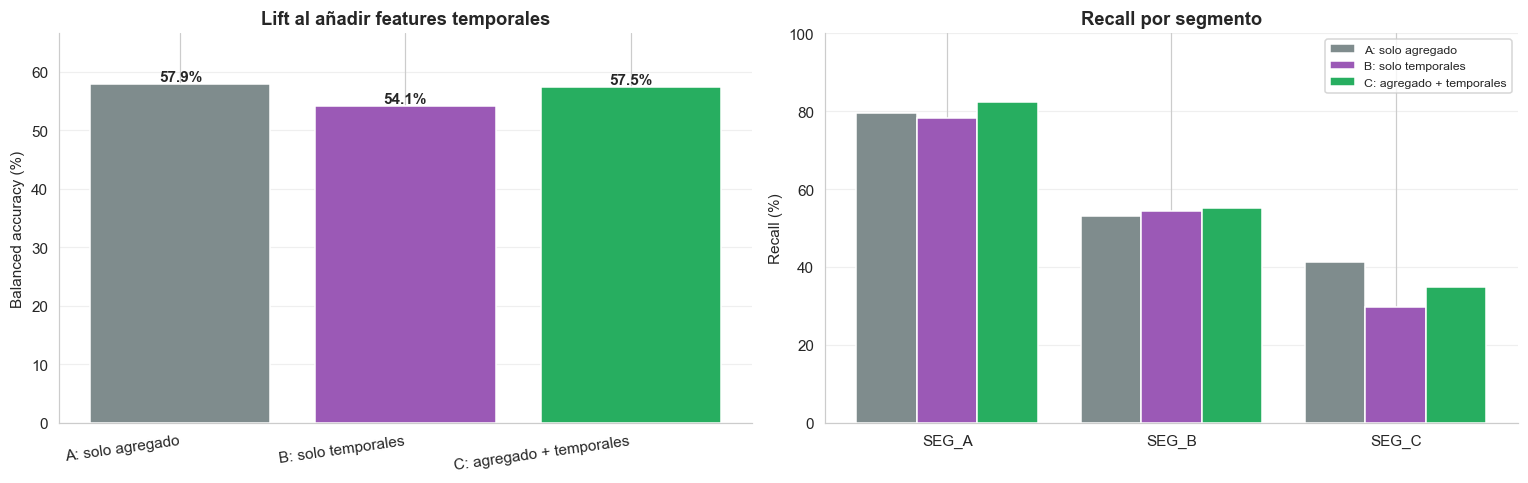

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# 1) Balanced accuracy bar
ax = axes[0]
xs = np.arange(len(results))
bars = ax.bar(xs, results['balanced_acc'],
              color=['#7f8c8d', '#9b59b6', '#27ae60'])
ax.set_xticks(xs); ax.set_xticklabels(results['label'], rotation=8, ha='right')
ax.set_ylabel('Balanced accuracy (%)')
ax.set_title('Lift al añadir features temporales', fontweight='bold')
for b, v in zip(bars, results['balanced_acc']):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%',
            ha='center', fontweight='bold')
ax.set_ylim(0, max(results['balanced_acc']) * 1.15)
ax.grid(axis='y', alpha=0.3)

# 2) Recall por clase
ax = axes[1]
w = 0.27
xs = np.arange(3)  # SEG_A, SEG_B, SEG_C
for i, (r, color) in enumerate(zip([A, B, C], ['#7f8c8d', '#9b59b6', '#27ae60'])):
    vals = [r['recall_A'], r['recall_B'], r['recall_C']]
    ax.bar(xs + (i-1)*w, vals, w, label=r['label'], color=color)
ax.set_xticks(xs); ax.set_xticklabels(LABELS)
ax.set_ylabel('Recall (%)')
ax.set_title('Recall por segmento', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)
plt.tight_layout(); plt.show()


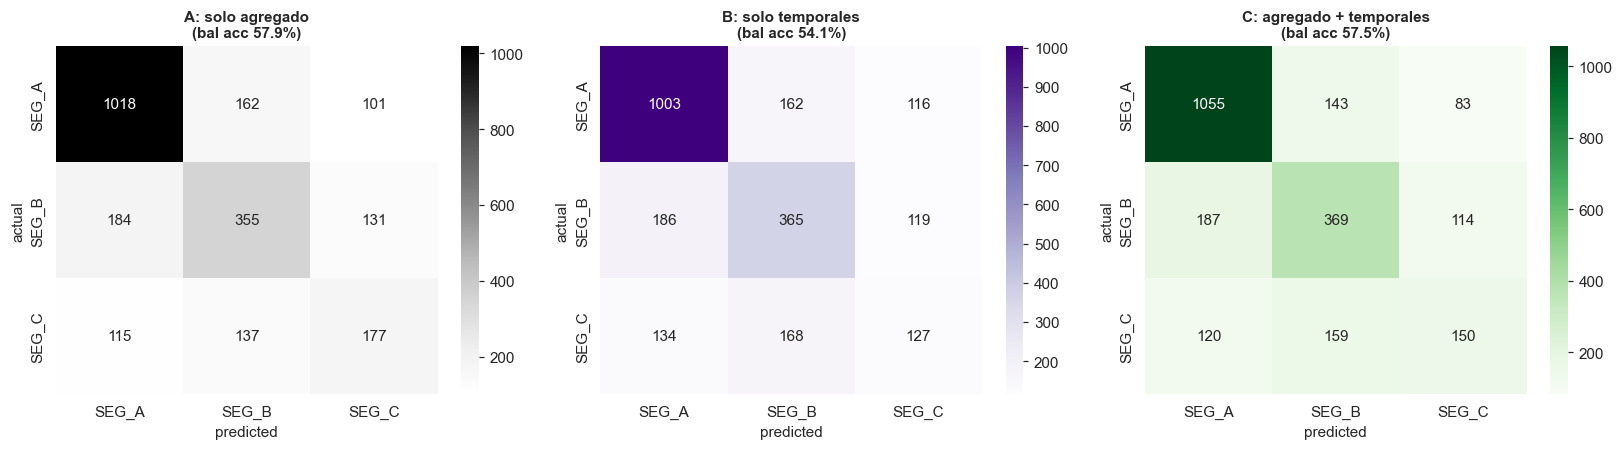

In [24]:
# Confusion matrices comparativas
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, r, cmap in zip(axes, [A, B, C], ['Greys', 'Purples', 'Greens']):
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap=cmap,
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(f"{r['label']}\n(bal acc {r['balanced_acc']:.1f}%)",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('predicted'); ax.set_ylabel('actual')
plt.tight_layout(); plt.show()


### Importancia de features (modelo C)
¿Qué pesa más el modelo combinado: las agregadas viejas o las temporales nuevas?


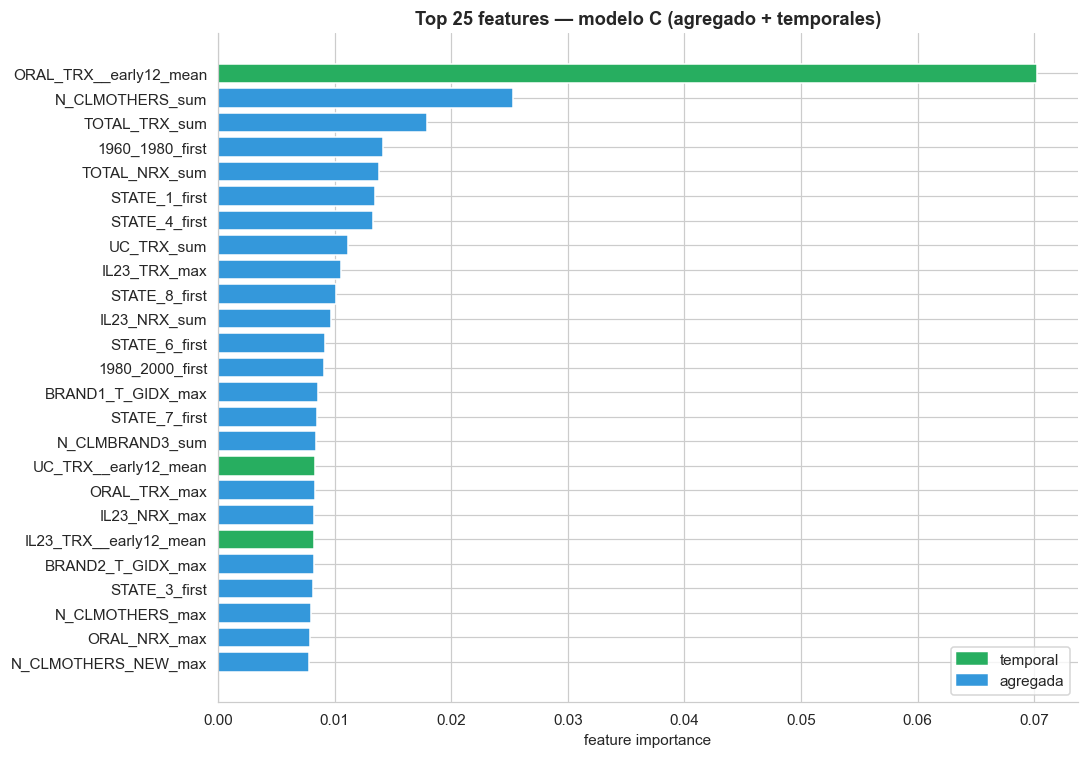

De las top 25, 3 son features temporales nuevas.


In [25]:
importance = pd.Series(C['model'].feature_importances_,
                       index=X_combined.columns).sort_values(ascending=False)
top = importance.head(25)

# Marcamos cuáles son temporales
is_temporal = top.index.str.contains('__')
colors = ['#27ae60' if t else '#3498db' for t in is_temporal]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
ax.set_xlabel('feature importance')
ax.set_title('Top 25 features — modelo C (agregado + temporales)',
             fontweight='bold')
# Leyenda manual
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#27ae60', label='temporal'),
                   Patch(color='#3498db', label='agregada')], loc='lower right')
plt.tight_layout(); plt.show()

print(f"De las top 25, {is_temporal.sum()} son features temporales nuevas.")


## 9. Próximos pasos para subir más

Una vez que veas el lift en la sección 8, hay varias direcciones que valen la pena
dependiendo de cuánto suba.

### Si subiste a 70-72% balanced acc → estás en el camino correcto, sigue iterando
1. **Más features temporales selectivas.** Aplica `temporal_features` también a
   `N_CLMBRAND1..4`, `N_CLMOTHERS_NEW`, `BRAND1_T_GIDX`, etc., guiándote por el ranking
   de AUC de la sección 6 (no las apliques a todas, generarías ruido).
2. **Ratios temporales.** `BRAND1_TRX__recent12_mean / BRAND2_TRX__recent12_mean`,
   `IL23_NBRX__acceleration / ORAL_NBRX__acceleration`. Suelen ser muy informativos
   en pharma porque reflejan *cambios de preferencia*.
3. **Buckets temporales.** En vez de `recent_12 / early_12`, prueba `Q1, Q2, Q3, Q4, Q5_Q6`
   (cuartiles más recientes) — el modelo a veces aprende mejor con ventanas explícitas.

### Si te quedaste cerca de 65-67% → el problema NO es solo feature engineering
1. **Modelo jerárquico de dos etapas.** Primero clasifica `SEG_B vs (SEG_A+SEG_C)` (es la
   clase residual, separable por *intensidad* de actividad). Luego, dentro de no-B,
   clasifica `SEG_A vs SEG_C` con un modelo **especializado** (otro XGBoost entrenado
   solo en esos 2 segmentos, posiblemente con un *threshold* de confianza).
2. **Confidence threshold + escalation.** El brief de Pfizer lo pide explícitamente
   ("Define confidence thresholds and escalation rules"). Si `proba_max < 0.55`, marca
   al HCP como "needs human review" en lugar de forzar una predicción mediocre.
3. **Modelo secuencial sobre la trayectoria cruda.** LSTM/GRU/TCN sobre la matriz
   `(86 semanas × N features)` por HCP. Suele dar +3-5 pp cuando la temporalidad es
   tan rica.
4. **Embeddings de trayectoria.** Aplica PCA/UMAP a la matriz aplanada `(11899, 86 * k)`
   para crear features de "tipo de trayectoria" — clusters latentes que el classifier
   puede usar.

### Reality check honesto
Si el reporte interno dice **35.8% de casos inherentemente difíciles** y **98.6% overlap
SEG_A/SEG_C en el espacio de features actual**, tienes un techo natural. Tu objetivo no
debería ser 90% sino:
- ~75% balanced accuracy global, y
- alto recall en SEG_C (la clase más valiosa para targeting), aceptando errores
  conscientes en SEG_B.

Eso es defendible y mucho más útil para Pfizer que un 65% plano.
